In [1]:
import cv2
import matplotlib.pyplot as plt
import os


Image loaded successfully.
Shape: (4000, 3000, 3)


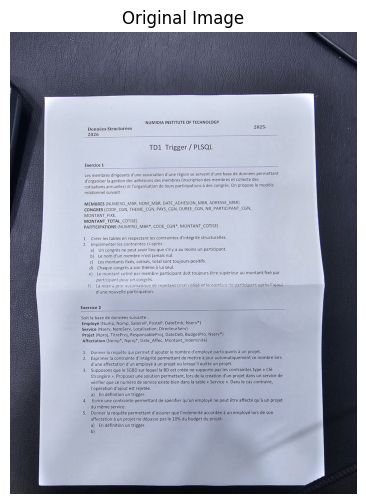

In [2]:

# image path
image_path = "/home/ali/DocuScan_OCR/dataset/images/test1.jpg"

# read image
img = cv2.imread(image_path)

# quick check
if img is None:
    print("Error: image not loaded. Check the file path.")
else:
    print("Image loaded successfully.")
    print("Shape:", img.shape)

# convert BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# display image
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [3]:


# save original copy
cv2.imwrite("../outputs/original_image.jpg", img)
print("Original image saved in outputs/")

Original image saved in outputs/


Image loaded ✅
Saved at: /home/ali/DocuScan_OCR/outputs/gray/test1.jpg


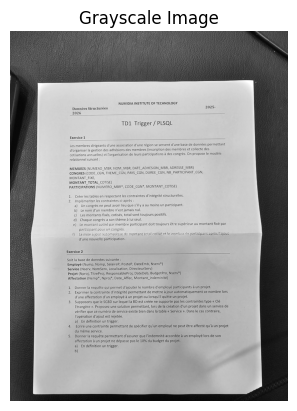

In [4]:

# input path
image_path = "../dataset/images/test1.jpg"

# read image
img = cv2.imread(image_path)

if img is None:
    print("Image not loaded ❌")
else:
    print("Image loaded ✅")

    # convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # create folder
    os.makedirs("../outputs/gray", exist_ok=True)

    # save image
    output_path = os.path.join("..", "outputs", "gray", "test1.jpg")
    cv2.imwrite(output_path, gray)

    print("Saved at:", os.path.abspath(output_path))

    # display
    plt.imshow(gray, cmap='gray')
    plt.title("Grayscale Image")
    plt.axis("off")
    plt.show()

Image loaded ✅
Saved at: /home/ali/DocuScan_OCR/outputs/blur/test1.jpg


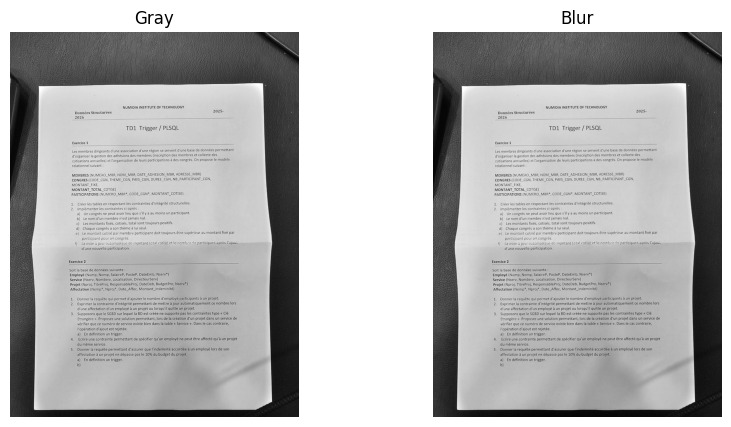

In [5]:
image_path = "../dataset/images/test1.jpg"

img = cv2.imread(image_path)

if img is None:
    print("Image not loaded ❌")
else:
    print("Image loaded ✅")

    # grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Gaussian Blur
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # create folder
    os.makedirs("../outputs/blur", exist_ok=True)

    # save
    output_path = os.path.join("..", "outputs", "blur", "test1.jpg")
    cv2.imwrite(output_path, blur)

    print("Saved at:", os.path.abspath(output_path))

    # display
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(gray, cmap='gray')
    plt.title("Gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(blur, cmap='gray')
    plt.title("Blur")
    plt.axis("off")

    plt.show()

Image loaded ✅
Edge images saved in ../outputs/edges/ ✅


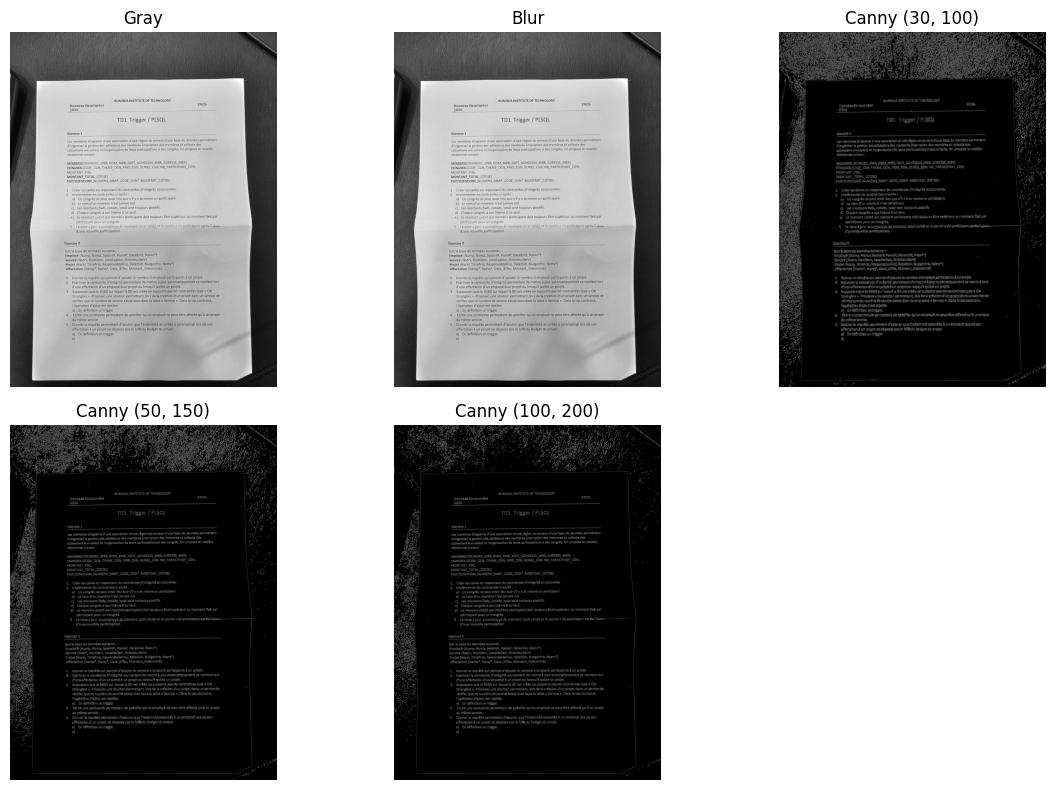

In [5]:
import cv2
import os
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read image
# -----------------------------
image_path = "../dataset/images/test1.jpg"
img = cv2.imread(image_path)

if img is None:
    print("Image not loaded ❌")
else:
    print("Image loaded ✅")

    # -----------------------------
    # 2. Convert to grayscale
    # -----------------------------
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # -----------------------------
    # 3. Apply Gaussian Blur
    # -----------------------------
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # -----------------------------
    # 4. Apply Canny Edge Detection
    # -----------------------------
    edges_low = cv2.Canny(blur, 30, 100)
    edges_default = cv2.Canny(blur, 50, 150)
    edges_high = cv2.Canny(blur, 100, 200)

    # -----------------------------
    # 5. Create output folder
    # -----------------------------
    os.makedirs("../outputs/edges", exist_ok=True)

    # -----------------------------
    # 6. Save edge images
    # -----------------------------
    cv2.imwrite("../outputs/edges/test1_edges_30_100.jpg", edges_low)
    cv2.imwrite("../outputs/edges/test1_edges_50_150.jpg", edges_default)
    cv2.imwrite("../outputs/edges/test1_edges_100_200.jpg", edges_high)

    print("Edge images saved in ../outputs/edges/ ✅")

    # -----------------------------
    # 7. Display results
    # -----------------------------
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap="gray")
    plt.title("Gray")
    plt.axis("off")

    plt.subplot(2, 3, 2)
    plt.imshow(blur, cmap="gray")
    plt.title("Blur")
    plt.axis("off")

    plt.subplot(2, 3, 3)
    plt.imshow(edges_low, cmap="gray")
    plt.title("Canny (30, 100)")
    plt.axis("off")

    plt.subplot(2, 3, 4)
    plt.imshow(edges_default, cmap="gray")
    plt.title("Canny (50, 150)")
    plt.axis("off")

    plt.subplot(2, 3, 5)
    plt.imshow(edges_high, cmap="gray")
    plt.title("Canny (100, 200)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

Image loaded ✅
Number of contours found: 20339
Document contour found ✅
Saved at: /home/ali/DocuScan_OCR/outputs/contours/test1_contour.jpg


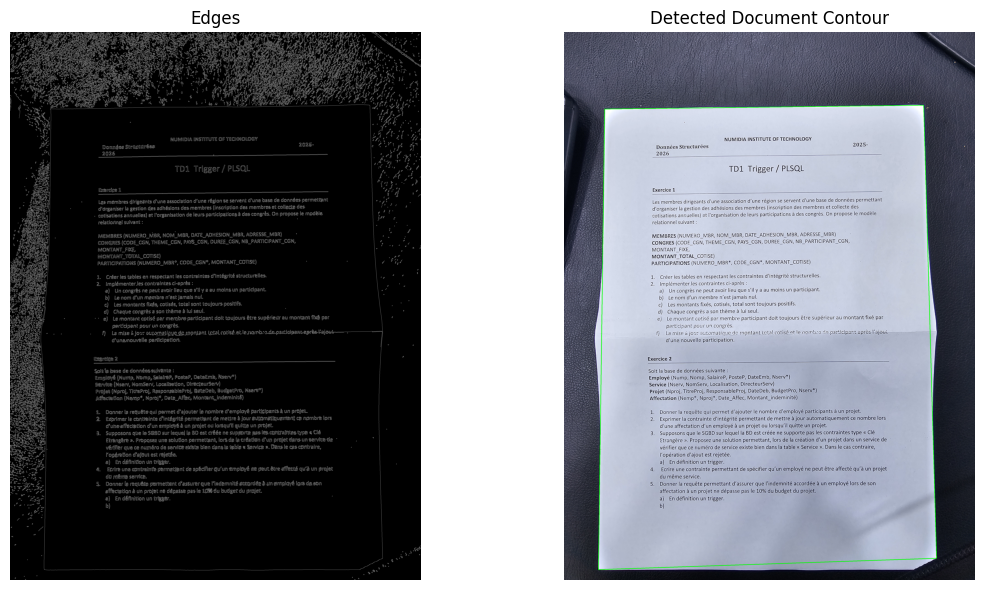

In [6]:
import cv2
import os
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read image
# -----------------------------
image_path = "../dataset/images/test1.jpg"
img = cv2.imread(image_path)

if img is None:
    print("Image not loaded ❌")
else:
    print("Image loaded ✅")

    # Keep a copy for drawing
    original = img.copy()

    # -----------------------------
    # 2. Grayscale
    # -----------------------------
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # -----------------------------
    # 3. Blur
    # -----------------------------
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # -----------------------------
    # 4. Edge detection
    # -----------------------------
    edges = cv2.Canny(blur, 50, 150)

    # -----------------------------
    # 5. Find contours
    # -----------------------------
    contours, _ = cv2.findContours(edges.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    print("Number of contours found:", len(contours))

    # -----------------------------
    # 6. Sort contours by area
    # -----------------------------
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    document_contour = None

    # -----------------------------
    # 7. Find largest quadrilateral
    # -----------------------------
    for contour in contours:
        perimeter = cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, 0.02 * perimeter, True)

        if len(approx) == 4:
            document_contour = approx
            break

    # -----------------------------
    # 8. Draw result
    # -----------------------------
    if document_contour is not None:
        cv2.drawContours(original, [document_contour], -1, (0, 255, 0), 3)
        print("Document contour found ✅")
    else:
        print("Document contour not found ❌")

    # -----------------------------
    # 9. Save result
    # -----------------------------
    os.makedirs("../outputs/contours", exist_ok=True)
    output_path = "../outputs/contours/test1_contour.jpg"
    cv2.imwrite(output_path, original)

    print("Saved at:", os.path.abspath(output_path))

    # -----------------------------
    # 10. Display results
    # -----------------------------
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(edges, cmap="gray")
    plt.title("Edges")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title("Detected Document Contour")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [7]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# ---------------------------------
# Helper function: order points
# ---------------------------------
def order_points(pts):
    pts = pts.reshape(4, 2)
    rect = np.zeros((4, 2), dtype="float32")

    # sum: top-left has smallest sum, bottom-right has largest sum
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # top-left
    rect[2] = pts[np.argmax(s)]   # bottom-right

    # diff: top-right has smallest diff, bottom-left has largest diff
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left

    return rect


# ---------------------------------
# Stage 1.6 - Perspective correction
# ---------------------------------
if document_contour is None:
    print("❌ No document contour found. Cannot apply perspective correction.")
else:
    # 1. Order the 4 corner points
    rect = order_points(document_contour)
    (tl, tr, br, bl) = rect

    # 2. Compute width of new image
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = int(max(widthA, widthB))

    # 3. Compute height of new image
    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = int(max(heightA, heightB))

    # 4. Destination points (top-down view)
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")

    # 5. Perspective transform matrix
    M = cv2.getPerspectiveTransform(rect, dst)

    # 6. Warp the image
    warped = cv2.warpPerspective(img_test, M, (maxWidth, maxHeight))

    # 7. Save result
    os.makedirs(OUTPUTS['warp'], exist_ok=True)
    cv2.imwrite(f"{OUTPUTS['warp']}/{name}.jpg", warped)

    print("✅ Perspective correction applied.")
    print(f"Saved warped image to: {OUTPUTS['warp']}/{name}.jpg")
    print("Ordered points:")
    print(rect)

    # 8. Display result
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
    plt.title("Detected Document Contour")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))
    plt.title("Warped Top-Down View")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

NameError: name 'img_test' is not defined